In [1]:
import sympy
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from scipy.stats import chi2
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import sys, os
sys.path.append(os.path.abspath('..'))
from se2 import se2_exp, se2_Ad


In [2]:
def ES_EKF():
    # Initialize variables
    x_nom           = ca.SX.sym("x_nom", 3)
    P         = ca.SX.sym("P", 3, 3)
    v         = ca.SX.sym("v")
    w         = ca.SX.sym("w")
    dt        = ca.SX.sym("dt")
    sigma_v   = ca.SX.sym("sigma_v")
    sigma_w   = ca.SX.sym("sigma_w")
    sigma_gps = ca.SX.sym("sigma_gps")
    z_gps     = ca.SX.sym("z_gps", 2)
    gps_flag  = ca.SX.sym("gps_flag")

    A_error = ca.vertcat(
    ca.horzcat( 1,      w*dt,  0     ),
    ca.horzcat(-w*dt,   1,     v*dt  ),
    ca.horzcat( 0,      0,     1     )
    )
    H = ca.vertcat(
    ca.horzcat(ca.cos(x_nom[2]), -ca.sin(x_nom[2]), 0),
    ca.horzcat(ca.sin(x_nom[2]),  ca.cos(x_nom[2]), 0)
    )
    Q_body = ca.diag(ca.vertcat(sigma_v**2, 0, sigma_w**2))
    Q_gps = ca.diag(ca.vertcat(sigma_gps**2, sigma_gps**2))

    # Propagate state
    x_prop = ca.vertcat(x_nom[0] + v*ca.cos(x_nom[2])*dt,
                        x_nom[1] + v*ca.sin(x_nom[2])*dt,
                        x_nom[2] + w*dt)

    # Prediction
    P_pred = A_error @ P @ A_error.T + Q_body*dt**2

    p = ca.vertcat(x_prop[0], x_prop[1])

    # Update
    y = z_gps - p
    S = H @ P_pred @ H.T + Q_gps
    K = P_pred @ H.T @ ca.inv(S)
    P_meas = (ca.SX.eye(3) - K @ H) @ P_pred @ (ca.SX.eye(3) - K @ H).T + K @ Q_gps @ K.T
    de = K @ y

    x_meas = ca.vertcat(x_prop[0] + ca.cos(x_prop[2])*de[0] - ca.sin(x_prop[2])*de[1], 
                        x_prop[1] + ca.sin(x_prop[2])*de[0] + ca.cos(x_prop[2])*de[1], 
                        x_prop[2] + de[2])

    x_new = ca.if_else(gps_flag, x_meas, x_prop)
    P_new = ca.if_else(gps_flag, P_meas, P_pred)
    nu = ca.if_else(gps_flag, y.T @ ca.inv(S) @ y, np.nan)
    

    f_filter = ca.Function(
        "error_state_filter",
        [
            x_nom,
            P,
            v,
            w,
            dt,
            sigma_v,
            sigma_w,
            sigma_gps,
            z_gps,
            gps_flag
        ],
        [x_new, P_new, nu],
        [
            "x_nom",
            "P",
            "v",
            "w",
            "dt",
            "sigma_v",
            "sigma_w",
            "sigma_gps",
            "z_gps",
            "gps_flag"
        ],
        ["x_new", "P_new", "nu"],
    )
    return {"error_state_filter": f_filter}

In [3]:
def IEKF(X, P, v, w, dt, sigma_v, sigma_w, sigma_gps, z_gps, gps_flag):

    xi = np.array([v, 0, w])
    theta = np.arctan2(X[1, 0], X[0, 0])

    M = se2_exp(-np.array([v, 0, w]) * dt)   # 3x3 SE(2) matrix
    pose = np.array([M[0, 2],
                     M[1, 2],
                     np.arctan2(M[1, 0], M[0, 0])])
    A_k = se2_Ad(pose)

    H = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0]
    ])
    Q_body = np.diag(np.array([sigma_v**2, 0, sigma_w**2]))
    Q_gps = np.diag(np.array([sigma_gps**2, sigma_gps**2]))

    # Propagate state
    x_new = X[0, 2] + v * np.cos(theta) * dt
    y_new = X[1, 2] + v * np.sin(theta) * dt
    theta_new = theta + w * dt
    X = np.array([
        [np.cos(theta_new), -np.sin(theta_new), x_new],
        [np.sin(theta_new),  np.cos(theta_new), y_new],
        [0,                  0,                  1    ]
    ])

    # Prediction
    P = A_k @ P @ A_k.T + Q_body*dt**2

    if not gps_flag:
        return X, P, np.nan

    # Update
    p = np.array([X[0, 2], X[1, 2]])
    S = H @ P @ H.T + Q_gps
    K = P @ H.T @ np.linalg.inv(S)
    P = (np.eye(3) - K @ H) @ P @ (np.eye(3) - K @ H).T + K @ Q_gps @ K.T
    y = z_gps - p
    nu = y @ np.linalg.inv(S) @ y
    de = K @ y

    X = X @ se2_exp(de)

    return X, P, nu

In [4]:
class Model():
    def __init__(self):
        self.x = sympy.symbols('x')
        self.y = sympy.symbols('y')
        self.theta = sympy.symbols('theta')
        self.dt = sympy.symbols('dt')
        self.v_nom = sympy.symbols('v_nom')
        self.w_ref = sympy.symbols('w_ref')
        self.P = sympy.MatrixSymbol('P', 3, 3)
    
    def dynamics(self):
        x_next = self.x + self.v_nom * sympy.cos(self.theta)*self.dt
        y_next = self.y + self.v_nom * sympy.sin(self.theta)*self.dt
        theta_next = self.theta + self.w_ref * self.dt
        return sympy.Matrix([x_next, y_next, theta_next])

    def state(self):
        return sympy.Matrix([self.x, self.y, self.theta])
    
    def Jacobian(self):
        return self.dynamics().jacobian(self.state())

    def Q_body(self):
        sigma_v, sigma_w = sympy.symbols('sigma_v sigma_w')
        return sympy.diag(sigma_v**2, 0, sigma_w**2)
    
    def Q(self):
        Lk = self.dt * sympy.Matrix([
            [sympy.cos(self.theta), 0, 0],
            [sympy.sin(self.theta), 0, 0],
            [0,                     0, 1]
        ])
        return Lk * self.Q_body() * Lk.T

    def measurement_noise(self):
        sigma_gps = sympy.symbols('sigma_gps')
        R = sigma_gps**2 * sympy.eye(2)
        return R

    def measurement_jacobian(self):
        return sympy.Matrix([self.x, self.y]).jacobian(self.state())



In [5]:
class EKF():
    def __init__(self, model):
        syms = [model.x, model.y, model.theta, model.v_nom, model.w_ref, model.dt]
        noise_syms = sympy.symbols('sigma_v sigma_w sigma_gps')

        self.f = sympy.lambdify(syms, model.dynamics(), 'numpy')
        self.F = sympy.lambdify(syms, model.Jacobian(), 'numpy')
        self.Q = sympy.lambdify([model.theta, model.dt, noise_syms[0], noise_syms[1]], model.Q(), 'numpy')
        self.H = np.array(model.measurement_jacobian()).astype(float)
        self.R = sympy.lambdify([noise_syms[2]], model.measurement_noise(), 'numpy')

    def predict(self, x_est, P_est, v, w, dt, sigma_v, sigma_w):
        x_pred = np.array(self.f(*x_est, v, w, dt)).flatten()
        F_val = np.array(self.F(*x_est, v, w, dt)).astype(float)
        Q_val = np.array(self.Q(x_est[2], dt, sigma_v, sigma_w)).astype(float)
        P_pred = F_val @ P_est @ F_val.T + Q_val
        return x_pred, P_pred

    def update(self, x_pred, P_pred, z, sigma_gps):
        H = self.H
        R = np.array(self.R(sigma_gps)).astype(float)
        K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)
        x_est = x_pred + K @ (z - H @ x_pred)
        P_est = (np.eye(3) - K @ H) @ P_pred @ (np.eye(3) - K @ H).T + K @ R @ K.T
        return x_est, P_est

    def simulate_step(self, x_est, P_est, z, v, w, dt, sigma_v, sigma_w, sigma_gps):
        x_pred, P_pred = self.predict(x_est, P_est, v, w, dt, sigma_v, sigma_w)
        x_est, P_est = self.update(x_pred, P_pred, z, sigma_gps)
        return x_est, P_est
    

In [6]:
# Model
model = Model()
model.dynamics()
kf = EKF(model)
rng = np.random.default_rng(67676767)


In [7]:
# Constants
pi = np.pi

# Parameters
v_nom = 2
w_turn = 0.4
r_fig = 5
sigma_v = 1.0
sigma_w = 0.05
sigma_gps = 0.3
dt = 0.1

# Simulation parameters
T_lobe = 2 * pi / w_turn
T_fig8 = 10 * pi
T = 35
n_steps = int(T / dt)
gps_freq = 1

# Initial conditions
x0_true = np.array([0.0, 0.0, 0.0])
x0_est = np.array([0.0, 0.0, 0.0])
P0 = np.diag([0.01, 0.01, 0.01])
H = kf.H
R = np.array(kf.R(sigma_gps)).astype(float)

# Pre-compute reference inputs and GPS schedule
w_ref_vec = np.zeros(n_steps)
gps_flags = np.zeros(n_steps, dtype=bool)
for i in range(n_steps):
    t = i * dt
    w_ref_vec[i] = w_turn if t % T_fig8 < T_lobe else -w_turn
    gps_flags[i] = t % (1 / gps_freq) < 0.01

# Pre-generate noise so all filters use the same realization
noise_v = sigma_v * rng.standard_normal(n_steps)
noise_w = sigma_w * rng.standard_normal(n_steps)
noise_gps = rng.multivariate_normal(np.zeros(2), R, size=n_steps)

# Generate true trajectory and GPS measurements (shared by all filters)
x_true_hist = np.zeros((n_steps + 1, 3))
x_true_hist[0] = x0_true
z_hist = np.full((n_steps, 2), np.nan)

X_true = np.eye(3)
for i in range(n_steps):
    xi = np.array([v_nom + noise_v[i], 0, w_ref_vec[i] + noise_w[i]]) * dt
    X_true = X_true @ se2_exp(xi)
    x_true_hist[i+1] = [X_true[0, 2], X_true[1, 2], np.arctan2(X_true[1, 0], X_true[0, 0])]
    if gps_flags[i]:
        z_hist[i] = H @ x_true_hist[i+1] + noise_gps[i]

In [8]:
x_est_hist = np.zeros((n_steps + 1, 3))
P_est_hist = np.zeros((n_steps + 1, 3, 3))
x_est_hist[0] = x0_est
P_est_hist[0] = P0

x_est = x0_est.copy()
P_est = P0.copy()
for i in range(n_steps):
    x_est, P_est = kf.predict(x_est, P_est, v_nom, w_ref_vec[i], dt, sigma_v, sigma_w)
    if gps_flags[i]:
        x_est, P_est = kf.update(x_est, P_est, z_hist[i], sigma_gps)
    x_est_hist[i + 1] = x_est
    P_est_hist[i + 1] = P_est

In [9]:
x_est_hist_es = np.zeros((n_steps + 1, 3))
P_est_hist_es = np.zeros((n_steps + 1, 3, 3))
x_est_hist_es[0] = x0_est
P_est_hist_es[0] = P0

fns = ES_EKF()
es_ekf_fn = fns["error_state_filter"]

x_est = x0_est.copy()
P_est = P0.copy()
for i in range(n_steps):
    gps_flag = 1 if gps_flags[i] else 0
    z_gps = z_hist[i] if gps_flags[i] else np.zeros(2)
    x_est, P_est, _ = es_ekf_fn(
        x_est, P_est, v_nom, w_ref_vec[i], dt,
        sigma_v, sigma_w, sigma_gps, z_gps, gps_flag)
    x_est_hist_es[i + 1] = np.array(x_est).flatten()
    P_est_hist_es[i + 1] = np.array(P_est)

In [10]:
x_est_hist_iekf = np.zeros((n_steps + 1, 3))
P_est_hist_iekf = np.zeros((n_steps + 1, 3, 3))
x_est_hist_iekf[0] = x0_est
P_est_hist_iekf[0] = P0

X_est = np.eye(3)
P_est = P0.copy()
for i in range(n_steps):
    gps_flag = 1 if gps_flags[i] else 0
    z_gps = z_hist[i] if gps_flags[i] else np.zeros(2)
    X_est, P_est, _ = IEKF(
        X_est, P_est, v_nom, w_ref_vec[i], dt,
        sigma_v, sigma_w, sigma_gps, z_gps, gps_flag)
    x_est_hist_iekf[i + 1] = [X_est[0, 2], X_est[1, 2], np.arctan2(X_est[1, 0], X_est[0, 0])]
    P_est_hist_iekf[i + 1] = P_est

In [11]:
def cov_ellipse(P_2x2, center, n_std=3.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(P_2x2)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(eigvals)
    return Ellipse(xy=center, width=w, height=h, angle=angle,
                   fill=False, linewidth=1.5, **kwargs)

def body_to_world_cov(P, theta):
    R_th = np.array([[np.cos(theta), -np.sin(theta), 0],
                     [np.sin(theta),  np.cos(theta), 0],
                     [0, 0, 1]])
    return R_th @ P @ R_th.T

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.grid(True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Filter Comparison')

true_line, = ax.plot([], [], 'k-', linewidth=0.8, label='True')
ekf_line, = ax.plot([], [], 'b--', linewidth=1.2, label='EKF')
es_line, = ax.plot([], [], 'r-.', linewidth=1.2, label='ES-EKF')
iekf_line, = ax.plot([], [], color='purple', linestyle=':', linewidth=1.2, label='IEKF')
gps_scatter = ax.scatter([], [], c='green', s=15, marker='x', label='GPS', zorder=5, alpha=0.5)
ellipse_patch_ekf = None
ellipse_patch_es = None
ellipse_patch_iekf = None
ax.legend(loc='upper left')

pad = 2
ax.set_xlim(x_true_hist[:, 0].min() - pad, x_true_hist[:, 0].max() + pad)
ax.set_ylim(x_true_hist[:, 1].min() - pad, x_true_hist[:, 1].max() + pad)

skip = 5

def init():
    true_line.set_data([], [])
    ekf_line.set_data([], [])
    es_line.set_data([], [])
    iekf_line.set_data([], [])
    gps_scatter.set_offsets(np.empty((0, 2)))
    return true_line, ekf_line, es_line, iekf_line, gps_scatter

def animate(frame):
    global ellipse_patch_ekf, ellipse_patch_es, ellipse_patch_iekf
    k = frame * skip
    
    true_line.set_data(x_true_hist[:k+1, 0], x_true_hist[:k+1, 1])
    ekf_line.set_data(x_est_hist[:k+1, 0], x_est_hist[:k+1, 1])
    es_line.set_data(x_est_hist_es[:k+1, 0], x_est_hist_es[:k+1, 1])
    iekf_line.set_data(x_est_hist_iekf[:k+1, 0], x_est_hist_iekf[:k+1, 1])

    z_slice = z_hist[:k]
    gps_mask = ~np.isnan(z_slice[:, 0])
    if gps_mask.any():
        gps_scatter.set_offsets(z_slice[gps_mask])

    if ellipse_patch_ekf is not None:
        ellipse_patch_ekf.remove()
    ellipse_patch_ekf = cov_ellipse(P_est_hist[k, :2, :2], x_est_hist[k, :2], edgecolor='blue')
    ax.add_patch(ellipse_patch_ekf)

    if ellipse_patch_es is not None:
        ellipse_patch_es.remove()
    P_world_es = body_to_world_cov(P_est_hist_es[k], x_est_hist_es[k, 2])
    ellipse_patch_es = cov_ellipse(P_world_es[:2, :2], x_est_hist_es[k, :2], edgecolor='red')
    ax.add_patch(ellipse_patch_es)

    if ellipse_patch_iekf is not None:
        ellipse_patch_iekf.remove()
    P_world_iekf = body_to_world_cov(P_est_hist_iekf[k], x_est_hist_iekf[k, 2])
    ellipse_patch_iekf = cov_ellipse(P_world_iekf[:2, :2], x_est_hist_iekf[k, :2], edgecolor='purple')
    ax.add_patch(ellipse_patch_iekf)

    return true_line, ekf_line, es_line, iekf_line, gps_scatter, ellipse_patch_ekf, ellipse_patch_es, ellipse_patch_iekf

n_frames = (n_steps + 1) // skip
anim = FuncAnimation(fig, animate, init_func=init, frames=n_frames, interval=30, blit=False)
anim.save('filter_comparison.gif', writer='pillow', fps=30)
plt.close(fig)
print('Saved filter_comparison.gif')
HTML(anim.to_jshtml())

Saved filter_comparison.gif


In [12]:
N = 100
mc_rng = np.random.default_rng(12345)

epsilon_all_ekf  = np.zeros((N, n_steps))
nu_all_ekf       = np.full((N, n_steps), np.nan)
epsilon_all_es   = np.zeros((N, n_steps))
nu_all_es        = np.full((N, n_steps), np.nan)
epsilon_all_iekf = np.zeros((N, n_steps))
nu_all_iekf      = np.full((N, n_steps), np.nan)

fns = ES_EKF()
es_ekf_fn = fns["error_state_filter"]

for j in range(N):
    mc_nv  = sigma_v * mc_rng.standard_normal(n_steps)
    mc_nw  = sigma_w * mc_rng.standard_normal(n_steps)
    mc_gps = mc_rng.multivariate_normal(np.zeros(2), R, size=n_steps)

    X_true_mc = np.eye(3)
    x_true_mc = np.zeros((n_steps + 1, 3))
    x_true_mc[0] = x0_true
    z_mc = np.full((n_steps, 2), np.nan)

    for i in range(n_steps):
        xi = np.array([v_nom + mc_nv[i], 0, w_ref_vec[i] + mc_nw[i]]) * dt
        X_true_mc = X_true_mc @ se2_exp(xi)
        x_true_mc[i+1] = [X_true_mc[0,2], X_true_mc[1,2], np.arctan2(X_true_mc[1,0], X_true_mc[0,0])]
        if gps_flags[i]:
            z_mc[i] = H @ x_true_mc[i+1] + mc_gps[i]

    # --- EKF ---
    x_est = x0_est.copy(); P_est = P0.copy()
    for i in range(n_steps):
        x_true = x_true_mc[i+1]
        x_est, P_est = kf.predict(x_est, P_est, v_nom, w_ref_vec[i], dt, sigma_v, sigma_w)
        if gps_flags[i]:
            S = H @ P_est @ H.T + R
            innov = z_mc[i] - H @ x_est
            nu_all_ekf[j, i] = innov @ np.linalg.inv(S) @ innov
            x_est, P_est = kf.update(x_est, P_est, z_mc[i], sigma_gps)
        delta_x = x_true - x_est
        delta_x[2] = (delta_x[2] + np.pi) % (2*np.pi) - np.pi
        epsilon_all_ekf[j, i] = delta_x @ np.linalg.inv(P_est) @ delta_x

    # --- ES-EKF ---
    x_est = x0_est.copy(); P_est = P0.copy()
    for i in range(n_steps):
        x_true = x_true_mc[i+1]
        gps_flag = 1 if gps_flags[i] else 0
        z_gps = z_mc[i] if gps_flags[i] else np.zeros(2)
        x_est, P_est, nu_all_es[j, i] = es_ekf_fn(
            x_est, P_est, v_nom, w_ref_vec[i], dt,
            sigma_v, sigma_w, sigma_gps, z_gps, gps_flag)
        x_est = np.array(x_est).flatten()
        P_est = np.array(P_est)
        th = x_est[2]
        R_rot = np.array([[np.cos(th), np.sin(th)], [-np.sin(th), np.cos(th)]])
        dp_body = R_rot @ (x_true[:2] - x_est[:2])
        dtheta = (x_true[2] - x_est[2] + np.pi) % (2*np.pi) - np.pi
        eps = np.array([dp_body[0], dp_body[1], dtheta])
        epsilon_all_es[j, i] = eps @ np.linalg.inv(P_est) @ eps

    # --- IEKF ---
    X_est = np.eye(3); P_est = P0.copy()
    for i in range(n_steps):
        x_true = x_true_mc[i+1]
        gps_flag = 1 if gps_flags[i] else 0
        z_gps = z_mc[i] if gps_flags[i] else np.zeros(2)
        X_est, P_est, nis = IEKF(
            X_est, P_est, v_nom, w_ref_vec[i], dt,
            sigma_v, sigma_w, sigma_gps, z_gps, gps_flag)
        nu_all_iekf[j, i] = nis
        x_est = np.array([X_est[0,2], X_est[1,2], np.arctan2(X_est[1,0], X_est[0,0])])
        th = x_est[2]
        R_rot = np.array([[np.cos(th), np.sin(th)], [-np.sin(th), np.cos(th)]])
        dp_body = R_rot @ (x_true[:2] - x_est[:2])
        dtheta = (x_true[2] - x_est[2] + np.pi) % (2*np.pi) - np.pi
        eps = np.array([dp_body[0], dp_body[1], dtheta])
        epsilon_all_iekf[j, i] = eps @ np.linalg.inv(P_est) @ eps

epsilon_bar      = np.mean(epsilon_all_ekf, axis=0)
nu_bar           = np.nanmean(nu_all_ekf, axis=0)
epsilon_bar_es   = np.mean(epsilon_all_es, axis=0)
nu_bar_es        = np.nanmean(nu_all_es, axis=0)
epsilon_bar_iekf = np.mean(epsilon_all_iekf, axis=0)
nu_bar_iekf      = np.nanmean(nu_all_iekf, axis=0)


C:\Users\Yahor\AppData\Local\Temp\ipykernel_33248\2578342731.py:82: RuntimeWarning: Mean of empty slice
  nu_bar           = np.nanmean(nu_all_ekf, axis=0)
C:\Users\Yahor\AppData\Local\Temp\ipykernel_33248\2578342731.py:84: RuntimeWarning: Mean of empty slice
  nu_bar_es        = np.nanmean(nu_all_es, axis=0)
C:\Users\Yahor\AppData\Local\Temp\ipykernel_33248\2578342731.py:86: RuntimeWarning: Mean of empty slice
  nu_bar_iekf      = np.nanmean(nu_all_iekf, axis=0)


In [13]:
nx = 3
nz = 2

# NEES band
nees_lo = chi2.ppf(0.025, df=N*nx) / N
nees_hi = chi2.ppf(0.975, df=N*nx) / N

# NIS band
nis_lo = chi2.ppf(0.025, df=N*nz) / N
nis_hi = chi2.ppf(0.975, df=N*nz) / N

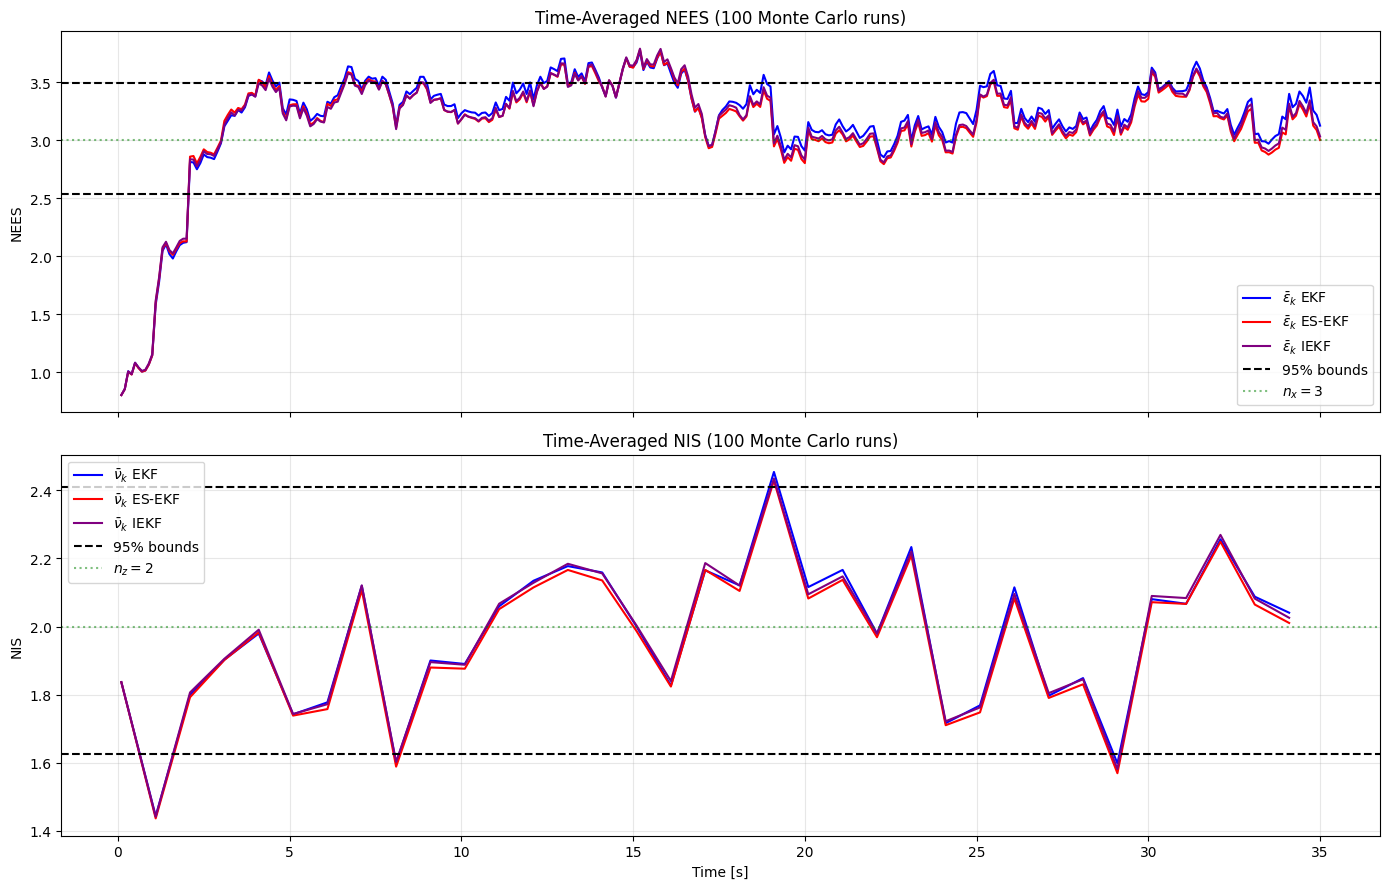

In [14]:
t_vec = np.arange(1, n_steps + 1) * dt

gps_mask = ~np.isnan(nu_bar)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.plot(t_vec, epsilon_bar, color='b', linewidth=1.5, label=r'$\bar{\epsilon}_k$ EKF')
ax1.plot(t_vec, epsilon_bar_es, color='r', linewidth=1.5, label=r'$\bar{\epsilon}_k$ ES-EKF')
ax1.plot(t_vec, epsilon_bar_iekf, color='purple', linewidth=1.5, label=r'$\bar{\epsilon}_k$ IEKF')
ax1.axhline(nees_lo, color='k', linestyle='--', label='95% bounds')
ax1.axhline(nees_hi, color='k', linestyle='--')
ax1.axhline(nx, color='g', linestyle=':', alpha=0.5, label=r'$n_x = 3$')
ax1.set_ylabel('NEES')
ax1.set_title(f'Time-Averaged NEES ({N} Monte Carlo runs)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_vec[gps_mask], nu_bar[gps_mask], color='b', linewidth=1.5, label=r'$\bar{\nu}_k$ EKF')
ax2.plot(t_vec[gps_mask], nu_bar_es[gps_mask], color='r', linewidth=1.5, label=r'$\bar{\nu}_k$ ES-EKF')
ax2.plot(t_vec[gps_mask], nu_bar_iekf[gps_mask], color='purple', linewidth=1.5, label=r'$\bar{\nu}_k$ IEKF')
ax2.axhline(nis_lo, color='k', linestyle='--', label='95% bounds')
ax2.axhline(nis_hi, color='k', linestyle='--')
ax2.axhline(nz, color='g', linestyle=':', alpha=0.5, label=r'$n_z = 2$')
ax2.set_ylabel('NIS')
ax2.set_xlabel('Time [s]')
ax2.set_title(f'Time-Averaged NIS ({N} Monte Carlo runs)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('NEES_NIS_comparison.png', dpi=150)
plt.show()

In [15]:
nees_avg_ekf  = np.mean(epsilon_bar)
nees_avg_es   = np.mean(epsilon_bar_es)
nees_avg_iekf = np.mean(epsilon_bar_iekf)

nis_avg_ekf  = np.nanmean(nu_bar)
nis_avg_es   = np.nanmean(nu_bar_es)
nis_avg_iekf = np.nanmean(nu_bar_iekf)

print(f"{'Filter':<12} {'NEES':>10} {'NIS':>10}")
print("-" * 34)
print(f"{'EKF':<12} {nees_avg_ekf:>10.4f} {nis_avg_ekf:>10.4f}")
print(f"{'ES-EKF':<12} {nees_avg_es:>10.4f} {nis_avg_es:>10.4f}")
print(f"{'IEKF':<12} {nees_avg_iekf:>10.4f} {nis_avg_iekf:>10.4f}")

Filter             NEES        NIS
----------------------------------
EKF              3.1928     1.9704
ES-EKF           3.1453     1.9563
IEKF             3.1566     1.9694
